In [1]:
import numpy as np
import matplotlib.pyplot as pyplot
import os
from ransac_benchmark_imc.io import load_h5





In [2]:
import re
from collections import defaultdict

def nested_dict():
    """Helper to create arbitrarily deep nested dictionaries."""
    return defaultdict(nested_dict)

def parse_prosac_dirs(dirnames):
    """
    Parses a list of dirname strings like:
    '_PROSAC-False_conf-0.99_inl_th-0.5_match_th-0.7_maxiter-1000'
    and returns a nested dict:
    D[inl_th][match_th][conf][max_iter] = original_string
    """
    pattern = re.compile(
        r"_PROSAC-(?P<PROSAC>[^_]+)_conf-(?P<conf>[^_]+)_inl_th-(?P<inl_th>[^_]+)_match_th-(?P<match_th>[^_]+)_maxiter-(?P<max_iter>[^_]+)"
    )
    
    D = nested_dict()
    
    for s in dirnames:
        m = pattern.match(s)
        if not m:
            continue  # skip malformed strings
        conf = m.group("conf")
        prosac = m.group("PROSAC")
        inl_th = m.group("inl_th")
        match_th = m.group("match_th")
        max_iter = m.group("max_iter")
        D[prosac][inl_th][match_th][conf][max_iter] = s
    
    return D


In [4]:
!ls ../results/val

f  f_roma


In [10]:
def parse_inl_th_dirs(dirnames):
    """
    Parses a list of dirname strings like:
    '_PROSAC-False_conf-0.99_inl_th-0.5_match_th-0.7_maxiter-1000'
    and returns a nested dict:
    D[inl_th][match_th][conf][max_iter] = original_string
    """
    pattern = re.compile(
        r"_PROSAC-(?P<PROSAC>[^_]+)_conf-(?P<conf>[^_]+)_inl_th-(?P<inl_th>[^_]+)_match_th-(?P<match_th>[^_]+)_maxiter-(?P<max_iter>[^_]+)"
    )
    
    D = nested_dict()
    
    for s in dirnames:
        m = pattern.match(s)
        if not m:
            continue  # skip malformed strings
        conf = m.group("conf")
        prosac = m.group("PROSAC")
        inl_th = m.group("inl_th")
        match_th = m.group("match_th")
        max_iter = m.group("max_iter")
        D[prosac][inl_th][match_th][conf][max_iter] = s
    
    return D


In [29]:
dict_for_plotting_th = {}
results_root_dir = '../results/val/f_roma/'
methods = [x for x in os.listdir(results_root_dir)]


for method in methods:
    cur_method_dir = os.path.join(results_root_dir, method)
    dirs = os.listdir(cur_method_dir)
    parsed = parse_prosac_dirs(dirs)
    print (f'{parsed.keys()=}')
    for prosac, v0 in parsed.items():
        cur_dict_for_plotting = {}
        cur_dict_for_plotting['name'] = method
        prosac = True if prosac=='True' else False
        cur_dict_for_plotting['PROSAC'] =prosac
        for inl_th, v in v0.items():
            for m_th, vv in v.items():
                cur_dict_for_plotting['snn_th'] = m_th
                for conf, vvv in vv.items():
                    if float(conf) not in cur_dict_for_plotting.keys():
                        cur_dict_for_plotting[float(conf)] = {}
                    for max_iters, dirname in vvv.items():
                        try:
                            pp = os.path.join(cur_method_dir, dirname, 'maa_FINAL.h5')
                            res = load_h5(pp)#['mAA']
                        except:
                            print (f'{pp} is missing')
                            continue
                        cur_dict_for_plotting[float(conf)][float(inl_th)] = res
        key1 = f'{method}'
        if prosac:
            key1 += ' PROSAC'
        print (f"{key1=}")
        dict_for_plotting_th[key1] = cur_dict_for_plotting
dict_for_plotting_th
                

parsed.keys()=dict_keys(['False'])
key1='degensac'
parsed.keys()=dict_keys(['False'])
key1='cv2f-ransac'
parsed.keys()=dict_keys(['False'])
key1='vibesac'
parsed.keys()=dict_keys(['False'])
key1='pycolmap'
parsed.keys()=dict_keys(['False'])
key1='cv2f-magsac'
parsed.keys()=dict_keys(['False'])
key1='poselib'


{'degensac': {'name': 'degensac',
  'PROSAC': False,
  'snn_th': '0.8',
  0.9999: {0.5: {'mAA': np.float32(0.9043737),
    'time': np.float64(0.5339515480482151)}},
  0.99: {0.5: {'mAA': np.float32(0.90274745),
    'time': np.float64(0.8648585079827892)},
   0.75: {'mAA': np.float32(0.894798), 'time': np.float64(0.9201712433687139)},
   0.25: {'mAA': np.float32(0.8971212),
    'time': np.float64(0.6887655712938585)},
   2.0: {'mAA': np.float32(0.8631717), 'time': np.float64(1.0130097828589784)},
   1.5: {'mAA': np.float32(0.8761414), 'time': np.float64(0.9803285900580772)},
   1.0: {'mAA': np.float32(0.88844454), 'time': np.float64(0.922847175866135)},
   3.0: {'mAA': np.float32(0.8492121),
    'time': np.float64(1.0465172964734768)}}},
 'cv2f-ransac': {'name': 'cv2f-ransac',
  'PROSAC': False,
  'snn_th': '0.8',
  0.9999: {0.5: {'mAA': np.float32(0.8414848),
    'time': np.float64(0.026911899017715693)}},
  0.99: {0.5: {'mAA': np.float32(0.83077776),
    'time': np.float64(0.040649132

In [31]:
dict_for_plotting = {}
results_root_dir = '../results/val/f_roma/'
methods = [x for x in os.listdir(results_root_dir)]


for method in methods:
    cur_method_dir = os.path.join(results_root_dir, method)
    dirs = os.listdir(cur_method_dir)
    parsed = parse_prosac_dirs(dirs)
    print (f'{parsed.keys()=}')
    for prosac, v0 in parsed.items():
        cur_dict_for_plotting = {}
        cur_dict_for_plotting['name'] = method
        prosac = True if prosac=='True' else False
        cur_dict_for_plotting['PROSAC'] =prosac
        for inl_th, v in v0.items():
            cur_dict_for_plotting['inl_th'] = inl_th
            for m_th, vv in v.items():
                cur_dict_for_plotting['snn_th'] = m_th
                for conf, vvv in vv.items():
                    cur_dict_for_plotting[float(conf)] = {}
                    for max_iters, dirname in vvv.items():
                        try:
                            pp = os.path.join(cur_method_dir, dirname, 'maa_FINAL.h5')
                            res = load_h5(pp)#['mAA']
                        except:
                            print (f'{pp} is missing')
                            continue
                        cur_dict_for_plotting[float(conf)][int(max_iters)] = res
        key1 = f'{method}'
        if prosac:
            key1 += ' PROSAC'
        print (f"{key1=}")
        dict_for_plotting[key1] = cur_dict_for_plotting
                

parsed.keys()=dict_keys(['False'])
key1='degensac'
parsed.keys()=dict_keys(['False'])
key1='cv2f-ransac'
parsed.keys()=dict_keys(['False'])
key1='vibesac'
parsed.keys()=dict_keys(['False'])
key1='pycolmap'
parsed.keys()=dict_keys(['False'])
key1='cv2f-magsac'
parsed.keys()=dict_keys(['False'])
key1='poselib'


In [32]:
import matplotlib.pyplot as plt
import matplotlib

def get_plot_defaults():
    return {
        'font_size_title': 32,
        'font_size_axes': 25,
        'font_size_ticks': 22,
        'font_size_legend': 22,
        'line_width': 3,
        'marker_size': 10,
        'dpi': 600,
    }

def make_like_colab(fig, ax):
    # use a gray background
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#E6E6E6')
    
    # draw solid white grid lines
    ax.grid(color='white', linestyle='solid')

    # hide axis spines
    for spine in ax.spines.values():
        spine.set_visible(False)


    # remove the notch on the ticks (but show the label)
    ax.tick_params(axis=u'both', which=u'both', length=0)
cmap = matplotlib.cm.get_cmap('tab20')
def get_plot_defaults():
    return {
        'font_size_title': 32,
        'font_size_axes': 25,
        'font_size_ticks': 22,
        'font_size_legend': 22,
        'line_width': 3,
        'marker_size': 10,
        'dpi': 600,
    }
defaults = get_plot_defaults()
    
    
color_dict = {
    'poselib': cmap(0),
    'pycolmap': cmap(1),
    
    'pygcransac': cmap(2),
    'sklearn-8pt': cmap(3),
    'sklearn-7pt': cmap(4),
    'sklearn-7pt-numba': cmap(5),
    'kornia-cpu': cmap(6),
    'numba-loransac-vibesac-old': cmap(7),
    'numba-loransac-vibesac': cmap(8),

    'vibesac': cmap(10),

    'degensac': cmap(11),
    'pyransac': cmap(19),
    'cv2f-ransac': cmap(12),
    'cv2f-magsac': cmap(13),
    'cv2f-gc': cmap(14),
    'bansac-loransac': cmap(15),

  
    'pymagsac': cmap(16),
    'pygcransac': cmap(17),

    'superansac': cmap(18),
}
def get_plot_defaults():
    return {
        'font_size_title': 32,
        'font_size_axes': 25,
        'font_size_ticks': 22,
        'font_size_legend': 22,
        'line_width': 3,
        'marker_size': 10,
        'dpi': 600,
    }

def make_like_colab(fig, ax):
    # use a gray background
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#E6E6E6')
    
    # draw solid white grid lines
    ax.grid(color='white', linestyle='solid')

    # hide axis spines
    for spine in ax.spines.values():
        spine.set_visible(False)


    # remove the notch on the ticks (but show the label)
    ax.tick_params(axis=u'both', which=u'both', length=0)
cmap = matplotlib.cm.get_cmap('tab20')
defaults = get_plot_defaults()
    

/tmp/ipykernel_8102/2353668157.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')
/tmp/ipykernel_8102/2353668157.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')


/tmp/ipykernel_8102/3482175019.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')
/tmp/ipykernel_8102/3482175019.py:140: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')


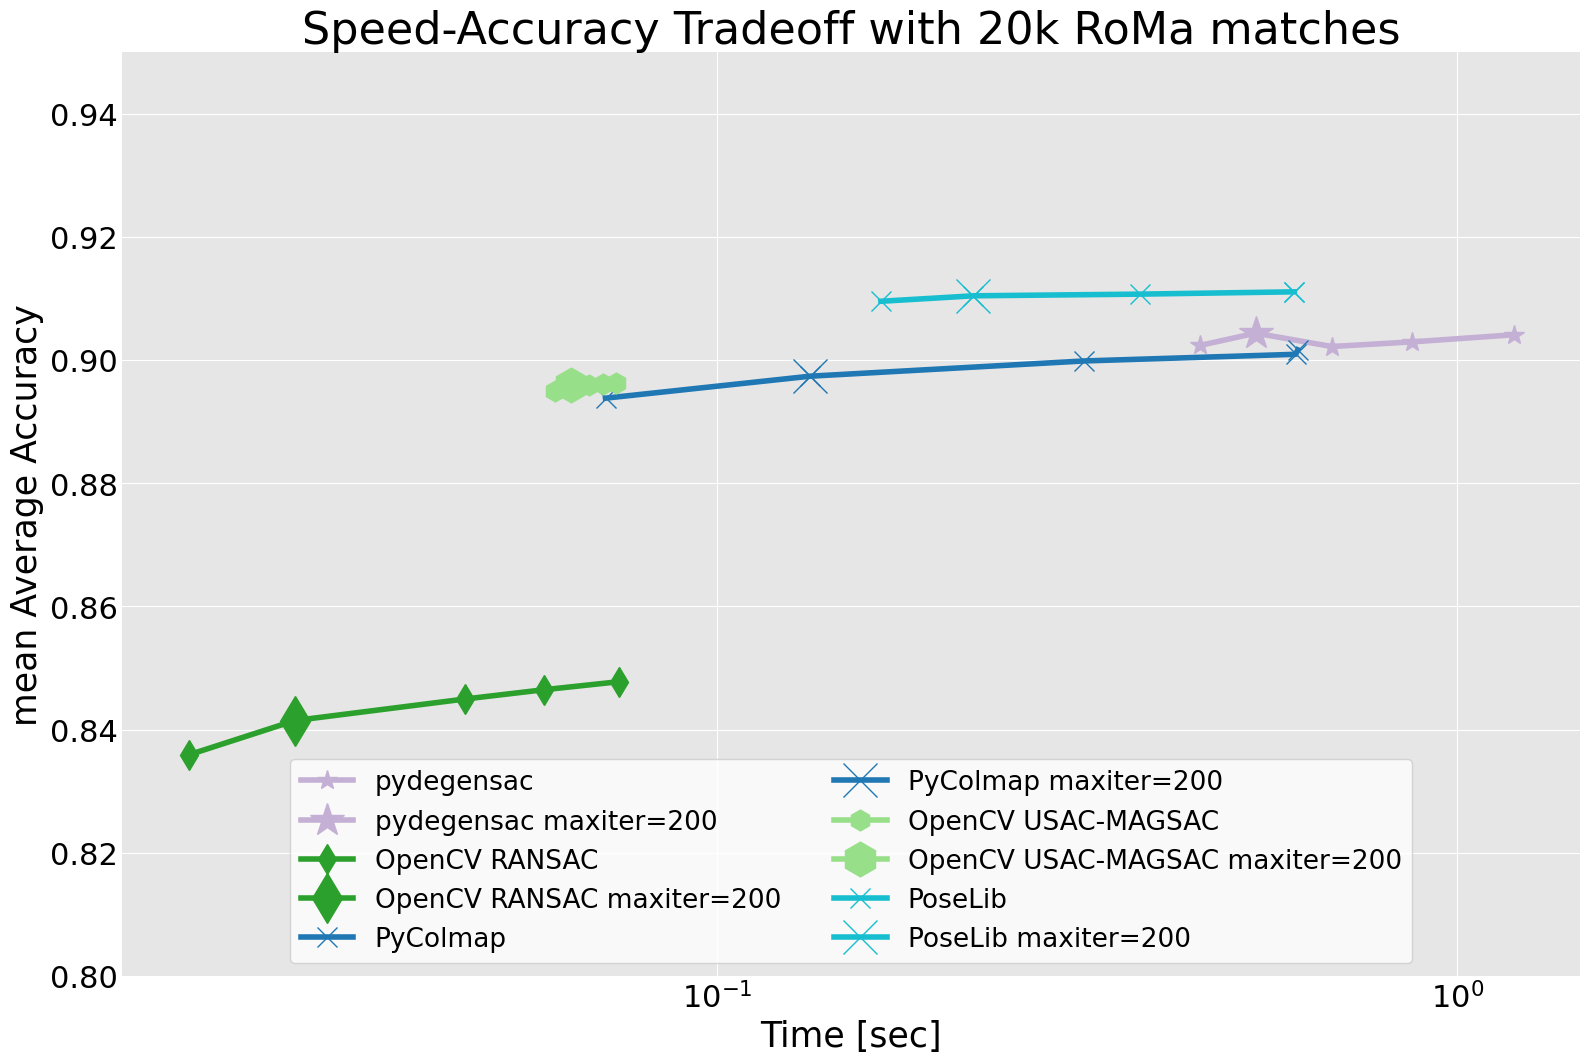

In [50]:
import matplotlib.pyplot as plt
cmap = matplotlib.cm.get_cmap('tab20')
method_renames = {
    'poselib': 'PoseLib',
    'cv2f-ransac': 'OpenCV RANSAC',
    'cv2f-magsac': 'OpenCV USAC-MAGSAC',
    'cv2f-loransac': 'OpenCV LO-RANSAC',
    'cv2f-gc': 'OpenCV GC-RANSAC',
    'superansac': 'SupeRANSAC',
    'pycolmap': 'PyColmap',
    'pygcransac': 'GC-RANSAC',
    'degensac': 'pydegensac',
    'sklearn-8pt': 'skimage-8pt',
    'vibesac': 'VibeSAC',
    'numba-loransac': 'Numba LoRANSAC',
    'bansac-loransac': 'OpenCV LORANSAC + BANSAC',
    'bansac-magsac': 'OpenCV MAGSAC + BANSAC',
    'bansac-ransac': 'OpenCV RANSAC + BANSAC',
    'bansac-gc': 'OpenCV GC-RANSAC + BANSAC',
    'pyransac': 'pydegensac (no degen)',
    
    
}
color_dict = {
    'pycolmap': cmap(0),
    'pycolmap PROSAC': cmap(0),
    'poselib': cmap(18),
    'poselib PROSAC': cmap(18),
    'superansac': cmap(2),
    'superansac PROSAC': cmap(2),
    'pygcransac': cmap(3),
    'pygcransac PROSAC': cmap(3),
    
    'cv2f-ransac': cmap(4),
    'cv2f-magsac': cmap(5),
    'cv2f-magsac PROSAC': cmap(5),
    'cv2f-gc': cmap(6),
    'cv2f-loransac': cmap(7),   
    'cv2f-loransac PROSAC': cmap(7),

    'pyransac': cmap(8),
    'degensac': cmap(9),
    'sklearn-8pt': cmap(10),
    'vibesac': cmap(11),
    'vibesac PROSAC': cmap(11),

   
    'bansac-loransac': cmap(7),
    'bansac-ransac': cmap(4),
    'bansac-magsac': cmap(5),
    
}

marker_dict_names = {
    'pycolmap': 'x',
    'poselib': 'x',
    'poselib PROSAC': 'x',
        'cv2f-loransac': 'x',
    'cv2f-loransac PROSAC':'x',
       'vibesac': 'x',
    'vibesac PROSAC': 'x',
        'pyransac': 'x',
         'pycolmap PROSAC': 'x',
            'bansac-loransac': 'x',
    
    'superansac': 'p',
    'superansac PROSAC': 'p',
    'pygcransac': 'p',
    'pygcransac PROSAC': 'p',
        'cv2f-gc': 'p',
    
    'cv2f-ransac': 'd',
    'sklearn-8pt': 'd',
        'bansac-ransac': 'd',
        
    'cv2f-magsac':'h',
    'cv2f-magsac PROSAC':'h',

 'bansac-magsac': 'h',
    


    'degensac': '*'


   


   
}
def get_name(m_name):
    if 'PROSAC' in m_name:
        basename = m_name.split(' ')[0]
        new_basename = method_renames[basename]
        return new_basename + ' PROSAC'
    return method_renames[m_name]

def get_plot_defaults():
    return {
        'font_size_title': 32,
        'font_size_axes': 25,
        'font_size_ticks': 22,
        'font_size_legend': 22,
        'line_width': 4,
        'marker_size': 10,
        'dpi': 600,
    }
defaults = get_plot_defaults()
linestyle_dict_names = {
    'pycolmap': '-',
    'pycolmap PROSAC': '-',
    'poselib': '-',
    'poselib PROSAC': '-.',
    'superansac': '-',
    'superansac PROSAC': '-.',
    'pygcransac': '-',
    'pygcransac PROSAC': '-.',
    
    
    'cv2f-ransac': '-',
    'cv2f-magsac':'-',
    'cv2f-magsac PROSAC':'-.',
    'cv2f-gc': '-',
    'cv2f-loransac': '-',
    'cv2f-loransac PROSAC':'-.',

    'pyransac': '-',
    'degensac': '-',
    'sklearn-8pt': '-',
    'vibesac': '-',
    'vibesac PROSAC': '-.',
    

   
    'bansac-loransac': '--',
    'bansac-ransac': '--',
    'bansac-magsac': '--',
}
fig, ax = plt.subplots(1, 1, figsize=(16,12))
cmap = matplotlib.cm.get_cmap('tab20')

ignore_list = ['bansac', 'pvsac', 'sklearn-7pt', 
               'sklearn-7pt-numba','numba-loransac',
               'numba-loransac-vibesac-old',
               'numba-loransac-vibesac PROSAC']
i = 0
added = []
conf1 = 0.9999
for m_name, v0 in dict_for_plotting.items():
    if 'vibe' in m_name:
        continue
    #if 'superansac' not in m_name:
    #    continuea
    if m_name in ignore_list:
        continue
    basename = m_name.split(' ')[0]
    for conf, conf_res in v0.items():
        if conf in ['inl_th', 'snn_th', 'name', 'PROSAC']:
            continue
        if conf!=conf1:
            continue
        maxiters = []
        maas = []
        times = []
        for max_iter, res in conf_res.items():
            maxiters.append(max_iter)
            try:
                if res['mAA']==0:
                    continue
            except:
                continue
            try:
                times.append(res['time'])
                maas.append(res['mAA'])
            except:
                continue
        if len(maas) == 0:
            continue
        if len(maas)!=len(maxiters):
            continue
        idxs = np.argsort(maxiters)
        maas = np.array(maas)[idxs]
        times = np.array(times)[idxs]
        maxiters = np.array(maxiters)[idxs]
        ax.semilogx(times, maas,
                           label=f'{get_name(m_name)}',
                    marker=marker_dict_names[m_name],
                    linestyle=linestyle_dict_names[m_name],
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size']+5,
                    color=color_dict[basename])
        iter1000 = np.where(maxiters==200)[0][0]
        ax.semilogx(times[iter1000], maas[iter1000],
                    marker=marker_dict_names[m_name],
                    linestyle=linestyle_dict_names[m_name],
                    label=f'{get_name(m_name)} maxiter=200',
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size']+15,
                    color=color_dict[basename])
        added.append(m_name)
    i += 1
    
ax.legend()

ax.set_ylabel('mean Average Accuracy', fontsize=defaults['font_size_axes'])
ax.set_xlabel('Time [sec]', fontsize=defaults['font_size_axes'])
ax.xaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
ax.yaxis.set_tick_params(labelsize=defaults['font_size_ticks'])

ax.set_title('Speed-Accuracy Tradeoff with 20k RoMa matches', fontsize=defaults['font_size_title'])
ax.set_ylim(0.8, 0.95)

make_like_colab(fig, ax)
ax.legend( prop={'size': defaults['font_size_legend'] - 3}, loc='lower center', ncol=2)
fig.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)
        
plt.savefig(f'roma-ransac-conf-{conf1}.pdf', bbox_inches='tight', dpi=defaults['dpi'])


/tmp/ipykernel_8102/2018760026.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('tab20')


res={'mAA': np.float32(0.8971212), 'time': np.float64(0.6887655712938585)}
res={'mAA': np.float32(0.90274745), 'time': np.float64(0.8648585079827892)}
res={'mAA': np.float32(0.894798), 'time': np.float64(0.9201712433687139)}
res={'mAA': np.float32(0.88844454), 'time': np.float64(0.922847175866135)}
res={'mAA': np.float32(0.8761414), 'time': np.float64(0.9803285900580772)}
res={'mAA': np.float32(0.8631717), 'time': np.float64(1.0130097828589784)}
res={'mAA': np.float32(0.8492121), 'time': np.float64(1.0465172964734768)}
maas=[np.float32(0.8971212), np.float32(0.90274745), np.float32(0.894798), np.float32(0.88844454), np.float32(0.8761414), np.float32(0.8631717), np.float32(0.8492121)] inl_ths=[0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
res=None
res=None
res=None
res=None
res=None


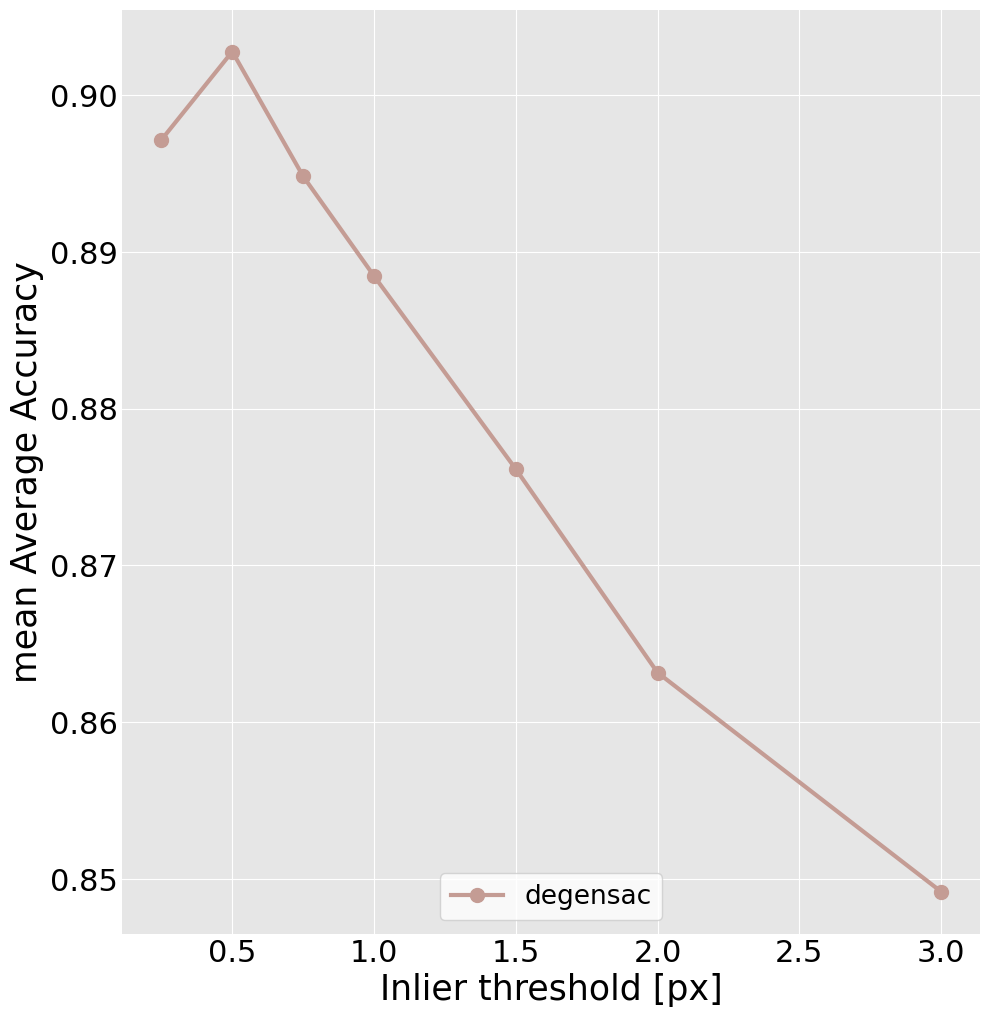

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,12))
cmap = matplotlib.cm.get_cmap('tab20')

ignore_list = ['bansac']
i = 0

for m_name, v0 in dict_for_plotting.items():
    #if 'superansac' not in m_name:
    #    continue
    if m_name in ignore_list:
        continue
    basename = m_name.split(' ')[0]
    for conf, conf_res in v0.items():
        if conf in ['inl_th', 'snn_th', 'name', 'PROSAC']:
            continue
        if conf!=0.99:
            continue
        maxiters = []
        maas = []
        times = []
        inl_ths = sorted([k for k in conf_res.keys()])
        for inl_th in inl_ths:
            res = conf_res[inl_th]
            print (f'{res=}')
            try:    
                if res['mAA']==0:
                    continue
            except:
                continue
            maas.append(res['mAA'])

        if len(maas) == 0:
            continue
        print (f'{maas=} {inl_ths=}')
        maas = np.array(maas)
        ax.plot(inl_ths, maas,
                    '-x' if 'PROSAC' in m_name else '-o',
                    label=f'{m_name}',
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size'],
                    color=color_dict[basename])
    i += 1
ax.legend()

ax.set_ylabel('mean Average Accuracy', fontsize=defaults['font_size_axes'])
ax.set_xlabel('Inlier threshold [px]', fontsize=defaults['font_size_axes'])
ax.xaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
ax.yaxis.set_tick_params(labelsize=defaults['font_size_ticks'])



make_like_colab(fig, ax)
ax.legend( prop={'size': defaults['font_size_legend'] - 3}, loc='lower center', ncol=1)
fig.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)
        
plt.savefig('ransac-roma-inl-th.pdf', bbox_inches='tight', dpi=defaults['dpi'])


In [7]:
dict_for_plotting = {}
results_root_dir = '../results/val/f_roma/'
methods = [x for x in os.listdir(results_root_dir)]


for method in methods:
    cur_method_dir = os.path.join(results_root_dir, method)
    dirs = os.listdir(cur_method_dir)
    parsed = parse_prosac_dirs(dirs)
    print (f'{parsed.keys()=}')
    for prosac, v0 in parsed.items():
        cur_dict_for_plotting = {}
        cur_dict_for_plotting['name'] = method
        prosac = True if prosac=='True' else False
        cur_dict_for_plotting['PROSAC'] =prosac
        for inl_th, v in v0.items():
            cur_dict_for_plotting['inl_th'] = inl_th
            for m_th, vv in v.items():
                cur_dict_for_plotting['snn_th'] = m_th
                for conf, vvv in vv.items():
                    cur_dict_for_plotting[float(conf)] = {}
                    for max_iters, dirname in vvv.items():
                        try:
                            pp = os.path.join(cur_method_dir, dirname, 'maa_FINAL.h5')
                            res = load_h5(pp)#['mAA']
                        except:
                            print (f'{pp} is missing')
                            continue
                        cur_dict_for_plotting[float(conf)][int(max_iters)] = res
        key1 = f'{method}'
        if prosac:
            key1 += ' PROSAC'
        print (f"{key1=}")
        dict_for_plotting[key1] = cur_dict_for_plotting
dict_for_plotting
                

parsed.keys()=dict_keys(['False'])
Cannot find file ../results/val/f_roma/degensac/_PROSAC-False_conf-0.99_inl_th-0.5_match_th-0.85_maxiter-1000/maa_FINAL.h5
key1='degensac'


{'degensac': {'name': 'degensac',
  'PROSAC': False,
  'inl_th': '0.5',
  'snn_th': '0.8',
  0.99: {1000: {'mAA': np.float32(0.90274745),
    'time': np.float64(0.8648585079827892)}}}}

In [ ]:
import matplotlib.pyplot as plt
cmap = matplotlib.cm.get_cmap('tab20')
color_dict = {
    'pycolmap': cmap(0),
    'pycolmap PROSAC': cmap(0),
    'poselib': cmap(18),
    'poselib PROSAC': cmap(18),
    'superansac': cmap(2),
    'superansac PROSAC': cmap(2),
    'pygcransac': cmap(3),
    'pygcransac PROSAC': cmap(3),
    
    'cv2f-ransac': cmap(4),
    'cv2f-magsac': cmap(5),
    'cv2f-magsac PROSAC': cmap(5),
    'cv2f-gc': cmap(6),
    'cv2f-loransac': cmap(7),   
    'cv2f-loransac PROSAC': cmap(7),

    'pyransac': cmap(8),
    'degensac': cmap(9),
    'sklearn-8pt': cmap(10),
    'vibesac': cmap(11),
    'vibesac PROSAC': cmap(11),

   
    'bansac-loransac': cmap(7),
    'bansac-ransac': cmap(4),
    'bansac-magsac': cmap(5),
    
}

marker_dict_names = {
    'pycolmap': 'x',
    'poselib': 'x',
    'poselib PROSAC': 'x',
        'cv2f-loransac': 'x',
    'cv2f-loransac PROSAC':'x',
       'vibesac': 'x',
    'vibesac PROSAC': 'x',
        'pyransac': 'x',
         'pycolmap PROSAC': 'x',
            'bansac-loransac': 'x',
    
    'superansac': 'p',
    'superansac PROSAC': 'p',
    'pygcransac': 'p',
    'pygcransac PROSAC': 'p',
        'cv2f-gc': 'p',
    
    'cv2f-ransac': 'd',
    'sklearn-8pt': 'd',
        'bansac-ransac': 'd',
        
    'cv2f-magsac':'h',
    'cv2f-magsac PROSAC':'h',

 'bansac-magsac': 'h',
    


    'degensac': '*'


   


   
}

def get_plot_defaults():
    return {
        'font_size_title': 32,
        'font_size_axes': 25,
        'font_size_ticks': 22,
        'font_size_legend': 22,
        'line_width': 4,
        'marker_size': 10,
        'dpi': 600,
    }
defaults = get_plot_defaults()
linestyle_dict_names = {
    'pycolmap': '-',
    'pycolmap PROSAC': '-',
    'poselib': '-',
    'poselib PROSAC': '-.',
    'superansac': '-',
    'superansac PROSAC': '-.',
    'pygcransac': '-',
    'pygcransac PROSAC': '-.',
    
    
    'cv2f-ransac': '-',
    'cv2f-magsac':'-',
    'cv2f-magsac PROSAC':'-.',
    'cv2f-gc': '-',
    'cv2f-loransac': '-',
    'cv2f-loransac PROSAC':'-.',

    'pyransac': '-',
    'degensac': '-',
    'sklearn-8pt': '-',
    'vibesac': '-',
    'vibesac PROSAC': '-.',
    

   
    'bansac-loransac': '--',
    'bansac-ransac': '--',
    'bansac-magsac': '--',
}
fig, ax = plt.subplots(1, 1, figsize=(16,12))
cmap = matplotlib.cm.get_cmap('tab20')

ignore_list = ['bansac', 'pvsac', 'sklearn-7pt', 
               'sklearn-7pt-numba','numba-loransac',
               'numba-loransac-vibesac-old',
               'numba-loransac-vibesac PROSAC']
i = 0
added = []
conf1 = 0.9999
for m_name in ['cv2f-magsac', 'cv2f-loransac', 'cv2f-gc', 'cv2f-ransac',
               'cv2f-magsac PROSAC', 'cv2f-loransac PROSAC']:
    try:
        v0 = dict_for_plotting[m_name]
    except:
        continue
    if 'vibe' in m_name:
        continue
    #if 'superansac' not in m_name:
    #    continuea
    if m_name in ignore_list:
        continue
    basename = m_name.split(' ')[0]
    for conf, conf_res in v0.items():
        if conf in ['inl_th', 'snn_th', 'name', 'PROSAC']:
            continue
        if conf!=conf1:
            continue
        maxiters = []
        maas = []
        times = []
        for max_iter, res in conf_res.items():
            maxiters.append(max_iter)
            try:
                if res['mAA']==0:
                    continue
            except:
                continue
            try:
                times.append(res['time'])
                maas.append(res['mAA'])
            except:
                continue
        if len(maas) == 0:
            continue
        if len(maas)!=len(maxiters):
            continue
        idxs = np.argsort(maxiters)
        maas = np.array(maas)[idxs]
        times = np.array(times)[idxs]
        maxiters = np.array(maxiters)[idxs]
        ax.semilogx(times, maas,
                           label=f'{get_name(m_name)}',
                    marker=marker_dict_names[m_name],
                    linestyle=linestyle_dict_names[m_name],
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size']+5,
                    color=color_dict[basename])
        iter1000 = np.where(maxiters==1000)[0][0]
        ax.semilogx(times[iter1000], maas[iter1000],
                    marker=marker_dict_names[m_name],
                    linestyle=linestyle_dict_names[m_name],
                    label=f'{get_name(m_name)} maxiter=1000',
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size']+25,
                    color=color_dict[basename])
        added.append(m_name)
    i += 1
for m_name in ['cv2f-magsac', 'cv2f-loransac', 'cv2f-gc', 'cv2f-ransac',
               'cv2f-magsac PROSAC', 'cv2f-loransac PROSAC']:
    try:
        v0 = dict_for_plotting_old[m_name]
    except:
        continue
    basename = m_name.split(' ')[0]
    for conf, conf_res in v0.items():
        if conf in ['inl_th', 'snn_th', 'name', 'PROSAC']:
            continue
        if conf!=0.9999:
            continue
        maxiters = []
        maas = []
        times = []
        for max_iter, res in conf_res.items():
            maxiters.append(max_iter)
            try:
                if res['mAA']==0:
                    continue
            except:
                continue
            try:
                times.append(res['time'])
                maas.append(res['mAA'])
            except:
                continue
        if len(maas) == 0:
            continue
        if len(maas)!=len(maxiters):
            continue
        idxs = np.argsort(maxiters)
        maas = np.array(maas)[idxs]
        times = np.array(times)[idxs]
        maxiters = np.array(maxiters)[idxs]
        if m_name == 'pycolmap':
            continue
        if m_name == 'pycolmap PROSAC':
            m_name = 'pycolmap'
        
        ax.semilogx(times, maas,
                    marker=marker_dict_names[m_name],
                    linestyle=linestyle_dict_names[m_name],
                    label=f'{get_name(m_name)}',
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size']+5,
                    color=color_dict[basename])
        iter1000 = np.where(maxiters==1000)[0][0]
        ax.semilogx(times[iter1000], maas[iter1000],
                    marker=marker_dict_names[m_name],
                    linestyle=linestyle_dict_names[m_name],
                    label=f'{get_name(m_name)} maxiter=1000',
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size']+25,
                    color=color_dict[basename])
        added.append(m_name)
    i += 1
    
ax.legend()

ax.set_ylabel('mean Average Accuracy', fontsize=defaults['font_size_axes'])
ax.set_xlabel('Time per image pair [sec]', fontsize=defaults['font_size_axes'])
ax.xaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
ax.yaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
ax.set_ylim(0.2, .5)
ax.set_title('OpenCV RANSACs', fontsize=defaults['font_size_title'])

ax.set_xlim(0, .5)
make_like_colab(fig, ax)
ax.legend( prop={'size': defaults['font_size_legend'] - 6}, loc='lower center', ncol=3)



fig.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)
        
plt.savefig(f'OpenCV-RANSAC-variants.pdf', bbox_inches='tight', dpi=defaults['dpi'])


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,12))
cmap = matplotlib.cm.get_cmap('tab20')

ignore_list = ['bansac']
i = 0

for m_name, v0 in dict_for_plotting.items():
    #if 'superansac' not in m_name:
    #    continue
    if m_name in ignore_list:
        continue
    basename = m_name.split(' ')[0]
    for conf, conf_res in v0.items():
        if conf in ['inl_th', 'snn_th', 'name', 'PROSAC']:
            continue
        if conf!=0.9999:
            continue
        maxiters = []
        maas = []
        times = []
        for max_iter, res in conf_res.items():
            maxiters.append(max_iter)
            try:
                if res['mAA']==0:
                    continue
            except:
                continue
            try:
                times.append(res['time'])
                maas.append(res['mAA'])
            except:
                continue
        if len(maas) == 0:
            continue
        if len(maas)!=len(maxiters):
            continue
        idxs = np.argsort(maxiters)
        maas = np.array(maas)[idxs]
        times = np.array(times)[idxs]
        maxiters = np.array(maxiters)[idxs]
        ax.semilogx(times, maas,
                    '-x' if 'PROSAC' in m_name else '-o',
                    label=f'{m_name}',
                    linewidth=defaults['line_width'], 
                    markersize=defaults['marker_size'],
                    color=color_dict[basename])
    i += 1
ax.legend()
ax.set_ylim(0, 0.5)

ax.set_ylabel('mean Average Accuracy', fontsize=defaults['font_size_axes'])
ax.set_xlabel('Time [sec]', fontsize=defaults['font_size_axes'])
ax.xaxis.set_tick_params(labelsize=defaults['font_size_ticks'])
ax.yaxis.set_tick_params(labelsize=defaults['font_size_ticks'])


ax.set_ylim(0, .5)
make_like_colab(fig, ax)
ax.legend( prop={'size': defaults['font_size_legend'] - 3}, loc='lower center', ncol=1)
fig.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)
        
plt.savefig('ransac-conf-0.99.pdf', bbox_inches='tight', dpi=defaults['dpi'])
